In [1]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from hierarchical_clustering import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as stats
from scipy.special import gamma



In [2]:
def generate_null_data(n, p, mu, sigma):
    mu = np.array(mu)  # Ensure mu is an array
    cov = (sigma ** 2) * np.eye(p)  # Covariance matrix
    return np.random.multivariate_normal(mu, cov, size=n)

def compute_nu(node,n):
    # return the projection direction from the given node
    G_1= np.array(node.left.points)
    G_2 = np.array(node.right.points)
    n_G1 = len(G_1)
    n_G2 = len(G_2)

    nu = np.zeros(n)

    nu[G_1] += 1/n_G1
    nu[G_2] -= 1/n_G2
    return nu

def naive_p_value(X, node, sigma=1,grid_width=25,ngrid= 1000):
    from scipy.stats import chi
    n = np.shape(X)[0]
    p = np.shape(X)[1]
    nu = compute_nu(node,n).reshape(-1,1)
    #obs_target = np.linalg.norm(X.T@nu)/(np.linalg.norm(nu)*sigma)
    # Extract cluster indices
    left_indices = node.left.points
    right_indices = node.right.points

    # Compute cluster means
    left_mean = np.mean(X[left_indices, :], axis=0)
    right_mean = np.mean(X[right_indices, :], axis=0)

    # Compute the Euclidean distance between cluster means
    obs_target = np.linalg.norm(left_mean - right_mean)

    # Compute the scaling factor
    n_left = len(left_indices)
    n_right = len(right_indices)
    scale_factor = sigma * np.sqrt(1 / n_left + 1 / n_right)
    '''
    stat_grid = np.linspace(0.00001, grid_width,
                                    num=ngrid)
    logWeights = np.zeros((ngrid,)) 
    for g in range(ngrid):
        logWeights[g] = (- 0.5 * (stat_grid[g])** 2 + (p-1)*np.log(stat_grid[g])
                        - (p / 2 - 1) * np.log(2))
    logWeights = logWeights - np.max(logWeights)
    density = np.exp(logWeights)/gamma(p/2)
    sum = 0
    num = 0
    for g in range(ngrid):
        sum += density[g]
        if stat_grid[g] >= obs_target:
            num += density[g]
    p_value = num/sum
    '''
    p_value = 1 - chi.cdf(obs_target/scale_factor, df=p)
    return p_value

def check_p_value_uniformity(n,p, sigma, K, tau,layer, num_trials=1000):
    p_values = []
    p_values_n = []
    mu = np.zeros(p)  

    for _ in range(num_trials):
        X = generate_null_data(n,p,mu,sigma)
        # Fit agglomerative clustering
        model = AgglomerativeClustering(X, tau=tau, n_clusters=K,linkage="single")
        model.fit()

        winning_nodes = list(model.existing_clusters_log.keys())
        key = winning_nodes[layer]
        node = key[0].parent
        p_value, obs,sel,sel_corrected,grid_upper, grid_lower = model.merge_inference(node,grid_width= 20, ncoarse=20,ngrid = 1000,sd=sigma)
        print("Original selection probability: ",np.min(sel))
        print("Selection probability: ",np.min(sel_corrected))
        p_value_n = naive_p_value(X,node)
        p_values.append(p_value)
        p_values_n.append(p_value_n)

    p_values = np.array(p_values)
    p_values_n = np.array(p_values_n)

    # Histogram for both p-values
    plt.figure(figsize=(8, 5))
    plt.hist(p_values, bins=20, density=True, alpha=0.5, color="blue", edgecolor="black", label="Selection-based p-value")
    plt.hist(p_values_n, bins=20, density=True, alpha=0.5, color="orange", edgecolor="black", label="Naive p-value")
    plt.axhline(1, color='red', linestyle='dashed', linewidth=2, label="Uniform(0,1)")
    plt.xlabel("P-value")
    plt.ylabel("Density")
    plt.title("Histogram of P-values Under the Null Hypothesis")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
    
    plt.figure(figsize=(8, 5))
    sns.ecdfplot(p_values, color="blue", label="Selection-based p-values")
    sns.ecdfplot(p_values_n, color="orange", label="Naive p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("P-value")
    plt.ylabel("ECDF")
    plt.title("Empirical CDF of P-values")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    # Q-Q Plot for both p-values
    plt.figure(figsize=(8, 5))
    sorted_p_values = np.sort(p_values)
    sorted_p_values_n = np.sort(p_values_n)
    theoretical_quantiles = np.linspace(0, 1, num_trials)

    plt.plot(theoretical_quantiles, sorted_p_values, marker='o', linestyle='', color="blue", label="Selection-based p-values")
    plt.plot(theoretical_quantiles, sorted_p_values_n, marker='o', linestyle='', color="orange", label="Naive p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("Theoretical Uniform Quantiles")
    plt.ylabel("Empirical P-values")
    plt.title("Q-Q Plot: P-values vs. Uniform(0,1)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

In [3]:
def log_ref_approx_plots_by_tau():
    tau_values = range(1,11)
    n = 20
    p = 2
    sigma = 1
    K = n-1
    layer = -1
    grid = np.linspace(0.00001, 15, num=1000)
    sel_values_dict = {tau: [] for tau in tau_values}
    for tau in tau_values:
        mu = np.zeros(p)
        X = generate_null_data(n,p,mu,sigma)
        model = AgglomerativeClustering(X,tau=tau, n_clusters=K,linkage="single")
        model.fit()
        
        winning_nodes = list(model.existing_clusters_log.keys())
        key = winning_nodes[layer]
        node = key[0].parent
        
        _, _, sel = model.merge_inference(node,grid_width= 15, ncoarse=20,sd=sigma)
        sel_values_dict[tau].append((sel))
        sel_values_dict[tau] = np.array(sel_values_dict[tau])
    plt.figure(figsize=(10, 6))
    for tau in tau_values:
        # Average sel values across trials for each grid point
        sel_values = sel_values_dict[tau].reshape(-1,1)
        plt.plot(grid, sel_values, label=f"tau = {tau}")
    print(sel_values_dict[3])
    plt.xlabel("Grid Value")
    plt.ylabel("Approximated Log Reference Value")
    plt.title("Approximated Log Reference Values Across Grid for Different tau")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
[[ -9.82123482  -9.83801889  -9.85482269  -9.87164621  -9.88848946
   -9.90535243  -9.92223512  -9.93913754  -9.95605969  -9.97300156
   -9.98996315 -10.00694447 -10.02394552 -10.04096629 -10.05800678
  -10.075067   -10.09214694 -10.10924661 -10.126366   -10.14350512
  -10.16066397 -10.17784253 -10.19504082 -10.21225884 -10.22949658
  -10.24675405 -10.26403124 -10.28132816 -10.2986448  -10.31598117
  -10.33333726 -10.35071307 -10.36810861 -10.38552388 -10.40295887
  -10.42041358 -10.43788802 -10.45538219 -10.47289607 -10.49042969
  -10.50798303 -10.52555609 -10.54314888 -10.56076139 -10.57839363
  -10.59604559 -10.61371728 -10.63140869 -10.64911983 -10.66685069
  -10.68460128 -10.70237159 -10.72016162 -10.73797139 -10.75580087
  -10.77365008 -10.79151902 -10.80940768 -10.82731606 -10.84524417
  -10.86319201 -10.88115957 -10.89914685 -10.91715386 -10.93518059
  -10.95322705 -10.97129323 -

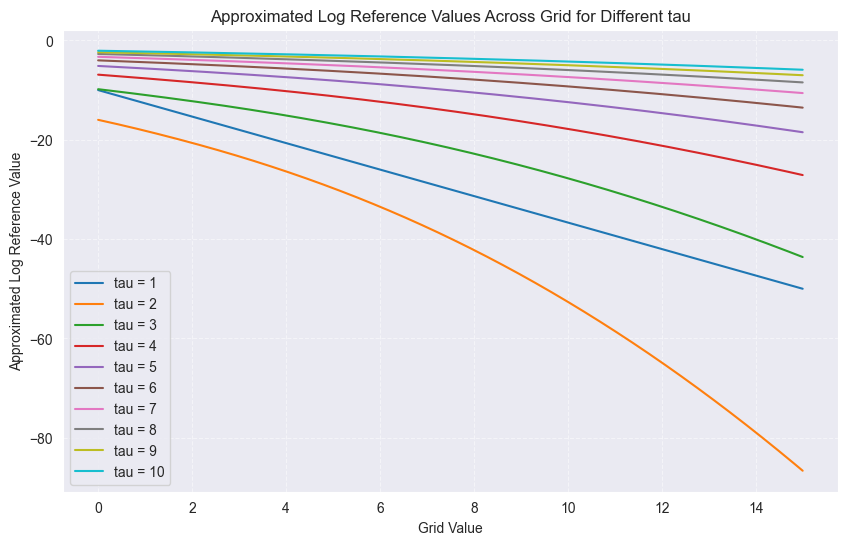

In [4]:
log_ref_approx_plots_by_tau()

In [4]:
def log_ref_approx_plots_by_p():
    tau = 1
    n = 20
    p_values = [2,5,10,15,20,30]
    sigma = 1
    K = n-1
    layer = -1
    grid = np.linspace(0.00001, 15, num=1000)
    sel_values_dict = {p: [] for p in p_values}
    for p in p_values:
        mu = np.zeros(p)
        X = generate_null_data(n,p,mu,sigma)
        model = AgglomerativeClustering(X,tau=tau, n_clusters=K,linkage="single")
        model.fit()
        
        winning_nodes = list(model.existing_clusters_log.keys())
        key = winning_nodes[layer]
        node = key[0].parent
        
        _, _, sel = model.merge_inference(node,grid_width= 15, ncoarse=20,sd=sigma)
        sel_values_dict[p].append(sel)
        sel_values_dict[p] = np.array(sel_values_dict[p])
    plt.figure(figsize=(10, 6))
    for p in p_values:
        # Average sel values across trials for each grid point
        sel_values = sel_values_dict[p].reshape(-1,1)
        plt.plot(grid, sel_values, label=f"p = {p}")

    plt.xlabel("Grid Value")
    plt.ylabel("Approximated Log Reference Value")
    plt.title("Approximated Log Reference Values Across Grid for Different p")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
def log_ref_approx_plots_by_n():
    tau = 3
    n_vals = [10,20,30,40,50]
    p = 2
    sigma = 1
    layer = -1
    grid = np.linspace(0.00001, 15, num=1000)
    sel_values_dict = {n: [] for n in n_vals}
    for n in n_vals:
        K = n-1
        mu = np.zeros(p)
        X = generate_null_data(n,p,mu,sigma)
        model = AgglomerativeClustering(X,tau=tau, n_clusters=K,linkage="single")
        model.fit()
        
        winning_nodes = list(model.existing_clusters_log.keys())
        key = winning_nodes[layer]
        node = key[0].parent
        
        _, _, sel = model.merge_inference(node,grid_width= 15, ncoarse=20,sd=sigma)
        sel_values_dict[n].append(sel)
        sel_values_dict[n] = np.array(sel_values_dict[n])
    plt.figure(figsize=(10, 6))
    for n in n_vals:
        # Average sel values across trials for each grid point
        sel_values = sel_values_dict[n].reshape(-1,1)
        plt.plot(grid, sel_values, label=f"n = {n}")

    plt.xlabel("Grid Value")
    plt.ylabel("Approximated Log Reference Value")
    plt.title("Approximated Log Reference Values Across Grid for Different n")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
def log_ref_approx_plots_by_sigma():
    tau = 1
    n = 20
    p = 2
    sigmas = [1,2,3,4,5]
    layer = -1
    grid = np.linspace(0.00001, 15, num=1000)
    sel_values_dict = {sigma: [] for sigma in sigmas}
    for sigma in sigmas:
        K = n-1
        mu = np.zeros(p)
        X = generate_null_data(n,p,mu,sigma)
        model = AgglomerativeClustering(X,tau=tau, n_clusters=K,linkage="single")
        model.fit()
        
        winning_nodes = list(model.existing_clusters_log.keys())
        key = winning_nodes[layer]
        node = key[0].parent
        
        _, _, sel = model.merge_inference(node,grid_width= 15, ncoarse=20,sd=sigma)
        sel_values_dict[sigma].append(sel)
        sel_values_dict[sigma] = np.array(sel_values_dict[sigma])
    plt.figure(figsize=(10, 6))
    for sigma in sigmas:
        # Average sel values across trials for each grid point
        sel_values = sel_values_dict[sigma].reshape(-1,1)
        plt.plot(grid, sel_values, label=f"sigma = {sigma}")

    plt.xlabel("Grid Value")
    plt.ylabel("Approximated Log Reference Value")
    plt.title("Approximated Log Reference Values Across Grid for Different sigma")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


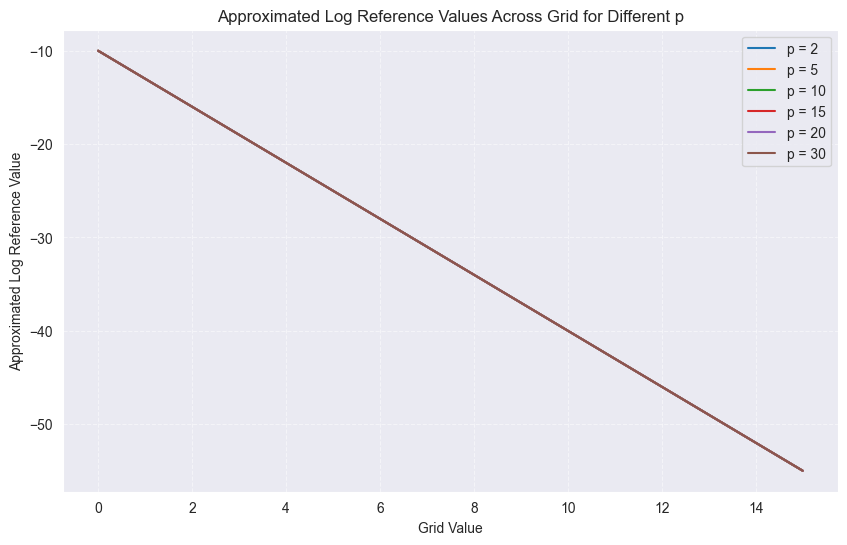

In [5]:
log_ref_approx_plots_by_p()

level:  1
level:  1
level:  1
level:  1
level:  1


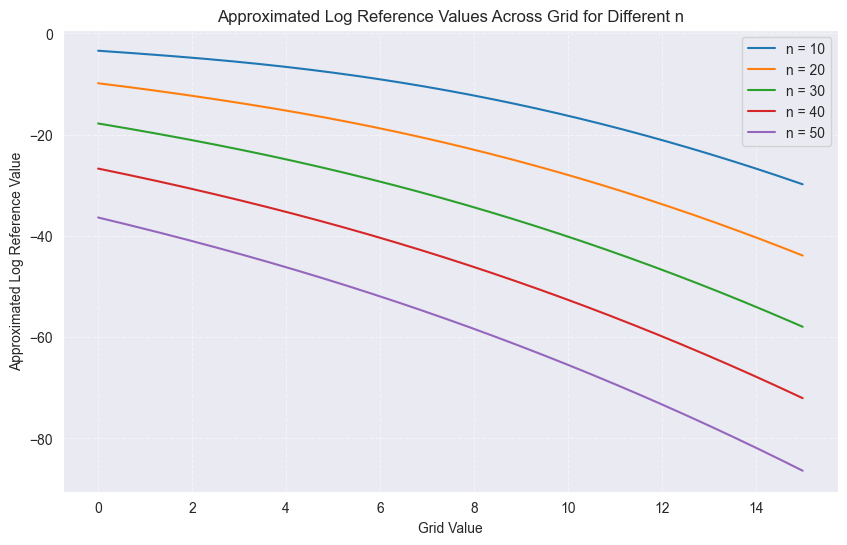

In [6]:
log_ref_approx_plots_by_n()

level:  1
level:  1
level:  1
level:  1
level:  1


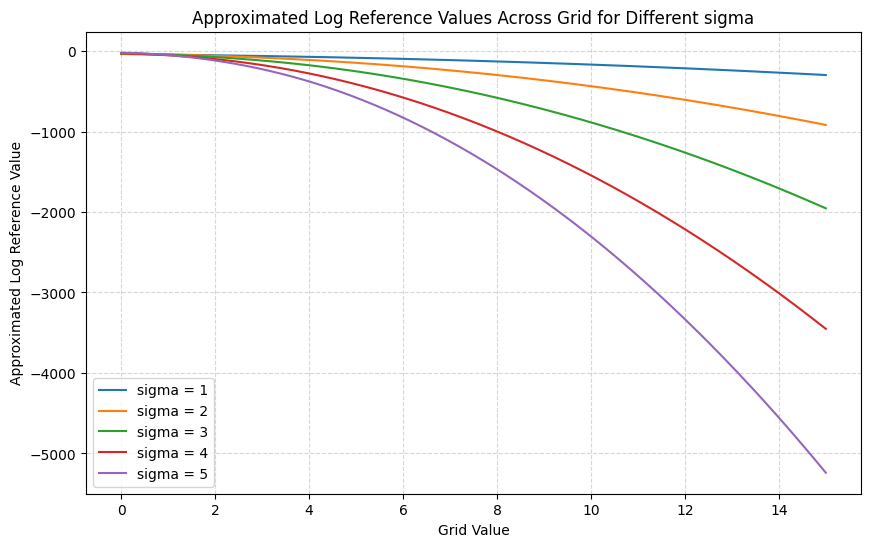

In [8]:
log_ref_approx_plots_by_sigma()

In [13]:
def log_ref_approx_plots_by_ncoarse():
    tau = 1
    n = 20
    p = 2
    ncoarse_vals = [20,100,200,500,1000]
    sigma = 1
    K = n-1
    layer = -1
    grid = np.linspace(0.00001, 15, num=1000)
    sel_values_dict = {ncoarse: [] for ncoarse in ncoarse_vals}
    for ncoarse in ncoarse_vals:
        mu = np.zeros(p)
        X = generate_null_data(n,p,mu,sigma)
        model = AgglomerativeClustering(X,tau=tau, n_clusters=K,linkage="single")
        model.fit()
        
        winning_nodes = list(model.existing_clusters_log.keys())
        key = winning_nodes[layer]
        node = key[0].parent
        
        _, _, sel = model.merge_inference(node,grid_width= 15, ncoarse=ncoarse,sd=sigma)
        sel_values_dict[ncoarse].append(sel)
        sel_values_dict[ncoarse] = np.array(sel_values_dict[ncoarse])
    plt.figure(figsize=(10, 6))
    for ncoarse in ncoarse_vals:
        # Average sel values across trials for each grid point
        sel_values = sel_values_dict[ncoarse].reshape(-1,1)
        plt.plot(grid, sel_values, label=f"ncoarse = {ncoarse}")

    plt.xlabel("Grid Value")
    plt.ylabel("Approximated Log Reference Value")
    plt.title("Approximated Log Reference Values Across Grid for Different ncoarse")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

In [14]:
log_ref_approx_plots_by_ncoarse()

level:  1
level:  1
level:  1


KeyboardInterrupt: 

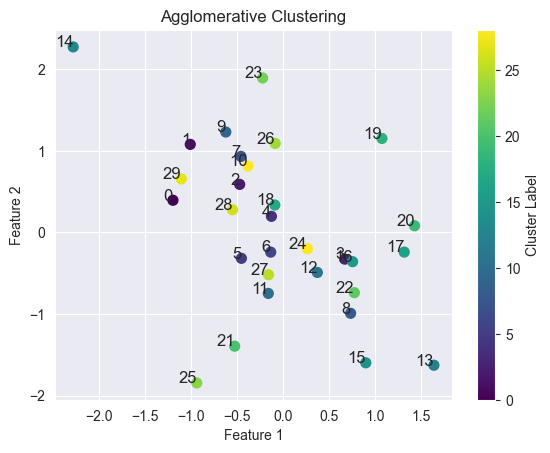

In [10]:
#X = np.random.uniform(-1, 1, size=(4, 2))
#X, y = make_blobs(n_samples=20, centers=19, cluster_std=1,random_state=42)
n=30
p=2
sigma=1
mu = np.zeros(p)  
X = generate_null_data(n,p,mu,sigma)
# Fit agglomerative clustering
model = AgglomerativeClustering(X, tau=np.log(20), n_clusters=29,linkage="single")
model.fit()
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)

# Assign cluster labels from the final cluster nodes
for idx, node in enumerate(model.cluster_nodes):
    for point_index in node.points:
        cluster_labels[point_index] = idx

    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

In [11]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[-1]
node = key[0].parent
pvalue, obs,sel_prob, sel_corrected, grid_upper,grid_lower = model.merge_inference(node, grid_width=20,ncoarse=20,ngrid=1000)
#pvalue, obs,sel_prob = model.merge_inference(node, grid_width=15,ncoarse=20,ngrid=1000)
np.min(sel_prob)

level:  1


np.float64(-80.80557874170796)

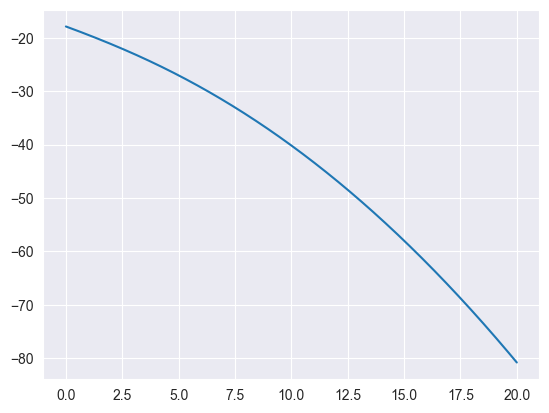

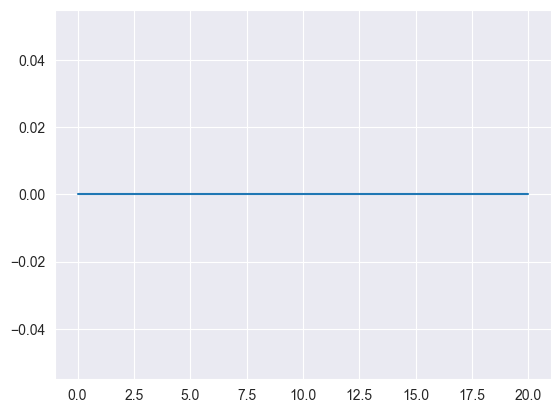

In [12]:
ref_norm_cor = (sel_corrected)
#x = np.linspace(0, 1.5*np.abs(obs_tar), 10000)
x = np.linspace(grid_lower, grid_upper,num=1000)
ref_norm = sel_prob
#x = np.linspace(0, 1.5*np.abs(obs_tar), 10000)
y = np.linspace(0.00001,20,num=1000)
plt.plot(y, ref_norm)
plt.show()
plt.plot(x, ref_norm_cor)
plt.show()

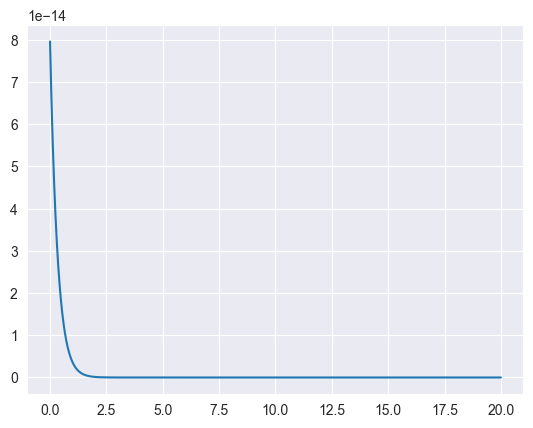

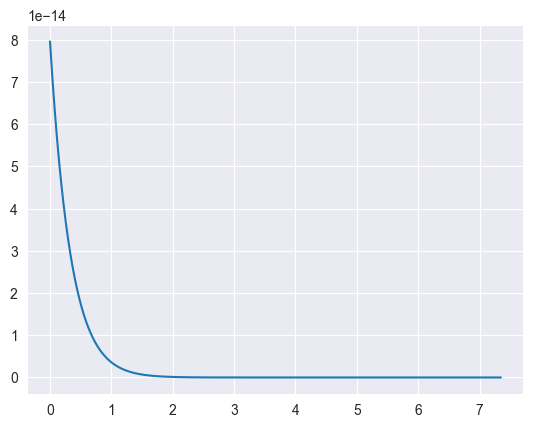

In [6]:
ref_norm_cor = np.exp(sel_corrected)
#x = np.linspace(0, 1.5*np.abs(obs_tar), 10000)
x = np.linspace(grid_lower, grid_upper,num=1000)
ref_norm = np.exp(sel_prob)
#x = np.linspace(0, 1.5*np.abs(obs_tar), 10000)
y = np.linspace(0.00001, 20,num=1000)
plt.plot(y, ref_norm)
plt.show()
plt.plot(x, ref_norm_cor)
plt.show()

In [44]:
sel_prob

array([-333.57815006, -333.57992968, -333.5808916 , -333.58103582,
       -333.58036233, -333.57887114, -333.57656225, -333.57343565,
       -333.56949135, -333.56472934, -333.55914963, -333.55275222,
       -333.5455371 , -333.53750428, -333.52865376, -333.51898553,
       -333.5084996 , -333.49719596, -333.48507462, -333.47213558,
       -333.45837883, -333.44380438, -333.42841223, -333.41220237,
       -333.39517481, -333.37732954, -333.35866657, -333.3391859 ,
       -333.31888753, -333.29777144, -333.27583766, -333.25308617,
       -333.22951698, -333.20513009, -333.17992549, -333.15390319,
       -333.12706318, -333.09940547, -333.07093006, -333.04163694,
       -333.01152612, -332.98059759, -332.94885136, -332.91628743,
       -332.8829058 , -332.84870646, -332.81368941, -332.77785467,
       -332.74120221, -332.70373206, -332.6654442 , -332.62633864,
       -332.58641537, -332.5456744 , -332.50411573, -332.46173935,
       -332.41854527, -332.37453349, -332.329704  , -332.28405

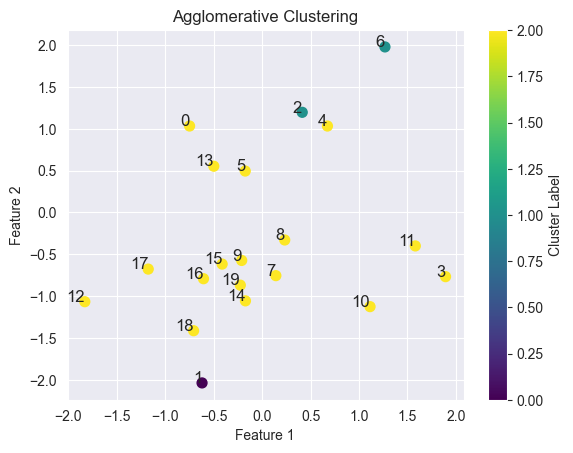

level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
-337.6366129889576
-353.76102727344073
528 36
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
-352.53923668429906
10.570575285285285


np.float64(-441.51760319829816)

In [7]:
#X = np.random.uniform(-1, 1, size=(4, 2))
#X, y = make_blobs(n_samples=20, centers=19, cluster_std=1,random_state=42)
n=20
p=2
sigma=1
mu = np.zeros(p)  
X = generate_null_data(n,p,mu,sigma)
# Fit agglomerative clustering
model = AgglomerativeClustering(X, tau=1, n_clusters=3,linkage="single")
model.fit()
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)

# Assign cluster labels from the final cluster nodes
for idx, node in enumerate(model.cluster_nodes):
    for point_index in node.points:
        cluster_labels[point_index] = idx

    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[-1]
node = key[0].parent
pvalue, obs,sel_prob, sel_corrected, grid_upper,grid_lower = model.merge_inference(node, grid_width=20,ncoarse=20,ngrid=1000)
#pvalue, obs,sel_prob = model.merge_inference(node, grid_width=15,ncoarse=20,ngrid=1000)
np.min(sel_prob)

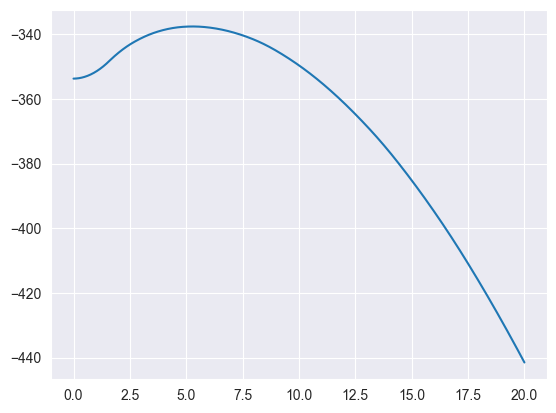

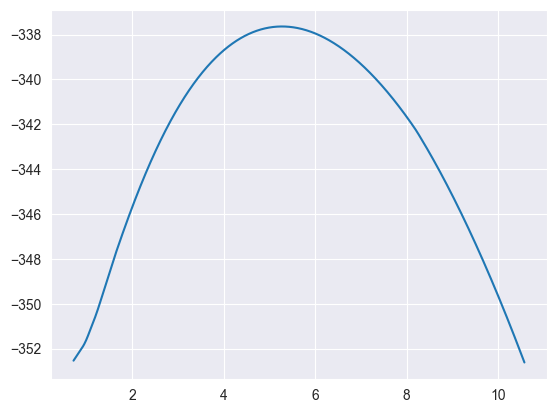

In [8]:
ref_norm_cor = (sel_corrected)
#x = np.linspace(0, 1.5*np.abs(obs_tar), 10000)
x = np.linspace(grid_lower, grid_upper,num=1000)
ref_norm = sel_prob
#x = np.linspace(0, 1.5*np.abs(obs_tar), 10000)
y = np.linspace(0.00001,20,num=1000)
plt.plot(y, ref_norm)
plt.show()
plt.plot(x, ref_norm_cor)
plt.show()

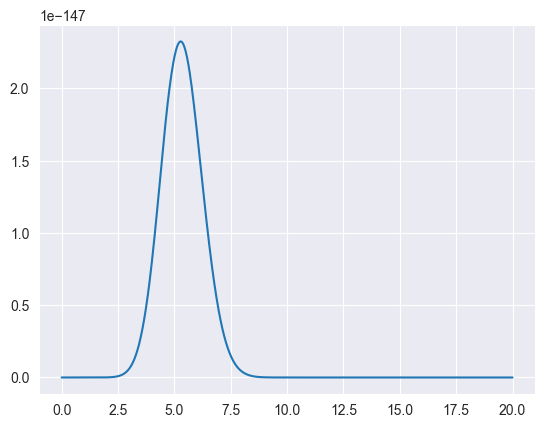

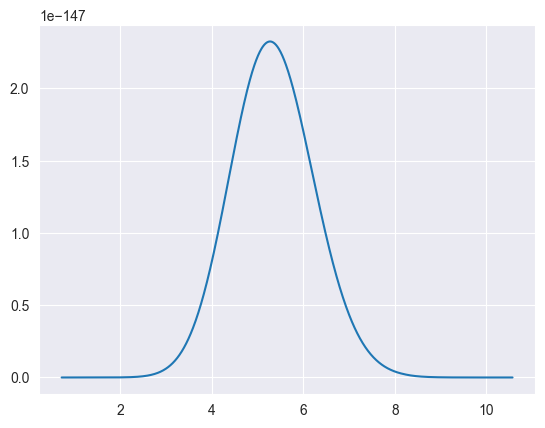

In [9]:
ref_norm_cor = np.exp(sel_corrected)
#x = np.linspace(0, 1.5*np.abs(obs_tar), 10000)
x = np.linspace(grid_lower, grid_upper,num=1000)
ref_norm = np.exp(sel_prob)
#x = np.linspace(0, 1.5*np.abs(obs_tar), 10000)
y = np.linspace(0.00001, 20,num=1000)
plt.plot(y, ref_norm)
plt.show()
plt.plot(x, ref_norm_cor)
plt.show()

In [11]:
n = X.shape[0]
def compute_nu(node):
    # return the projection direction from the given node
    G_1= np.array(node.left.points)
    G_2 = np.array(node.right.points)
    n_G1 = len(G_1)
    n_G2 = len(G_2)

    nu = np.zeros(n)

    nu[G_1] += 1/n_G1
    nu[G_2] -= 1/n_G2
    return nu

def compute_dirT(w):
    # return dir(w)^T
    norm = np.linalg.norm(w)
    dir_w = (w / norm) if norm != 0 else np.zeros_like(w)
    return dir_w.T
nu = compute_nu(node)

nuisance = (np.eye(n) - np.outer(nu,nu)/np.linalg.norm(nu)**2) @ X
contrast = X.T@nu
dir = compute_dirT(X.T@nu)
ngrid=100
grid_width=15
stat_grid = np.linspace(0.0001, grid_width, num=ngrid)

In [12]:
norm_nu = nu/np.linalg.norm(nu)
print(np.isclose(np.linalg.norm(X.T@norm_nu), np.linalg.norm(X.T@nu)/np.linalg.norm(nu)))

True


In [ ]:
model._approx_log_reference(node, stat_grid, nuisance,dir, sd=1)

level:  1
-2.8402530748479013
-2.8402530748479013
359 0
level:  1
-2.8402530748479013
7.1871935935935936
Original selection probability:  -256.0458817809865
Selection probability:  -32.69077901897657
level:  1
-3.654603681696769
-3.654603681696769
326 0
level:  1
-3.654603681696769
6.526533263263263
Original selection probability:  -286.69904383449534
Selection probability:  -33.4831924320387
level:  1
-2.8218546909688254
-2.8218546909688254
388 0
level:  1
-2.8218546909688254
7.767773883883884
Original selection probability:  -241.86897477560836
Selection probability:  -32.76314694702637
level:  1
-3.3693958500229804
-3.3693958500229804
347 0
level:  1
-3.3693958500229804
6.9469534734734735
Original selection probability:  -270.7996052743073
Selection probability:  -33.35750664522412
level:  1
-3.4769198743588965
-3.4769198743588965
348 0
level:  1
-3.4769198743588965
6.966973483483484
Original selection probability:  -269.8958887543729
Selection probability:  -33.33543785136929
level

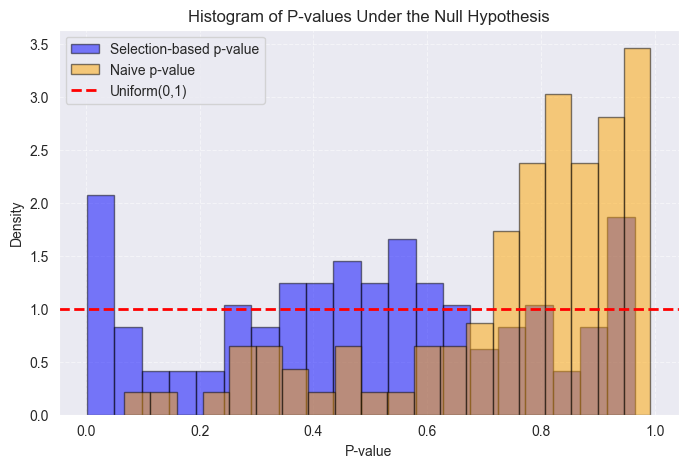

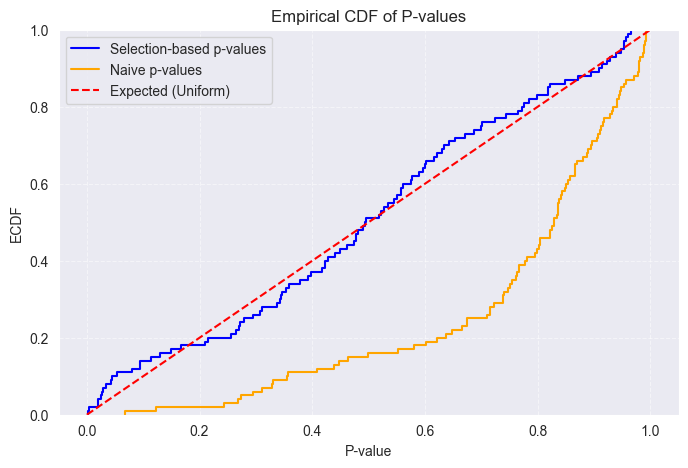

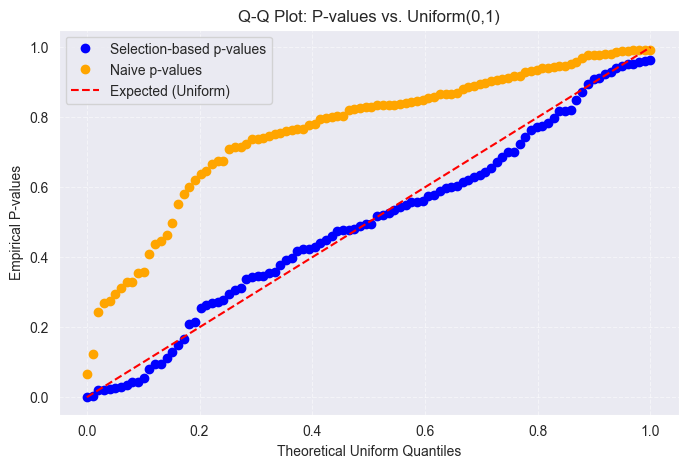

In [16]:
check_p_value_uniformity(5,2,1,4,1,-1,100)

level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
-325.08111946454005
-346.79125179834074
846 164
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
-340.0619150302017
16.93693846846847
Original selection probability:  -354.2561849149663
Selection probability:  -340.0644942890231
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
-334.81073340369096
-341.88750728674484
384 1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
-341.86071918881294
7.687693843843844
Original selection probability:  -516.5279443177978
Selection probability:  -341.8817808698036
level:  15
level:

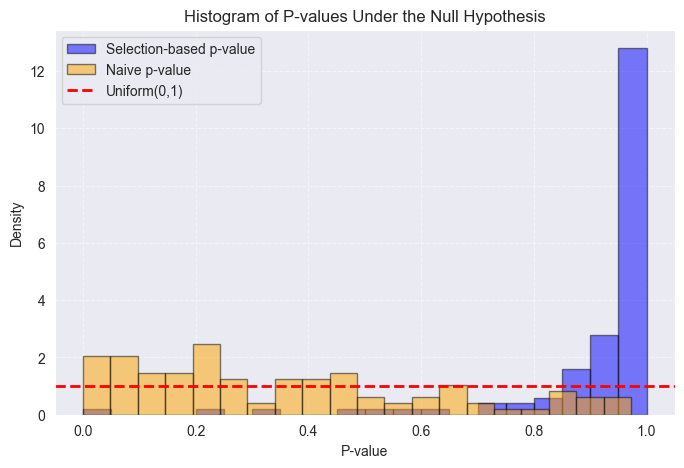

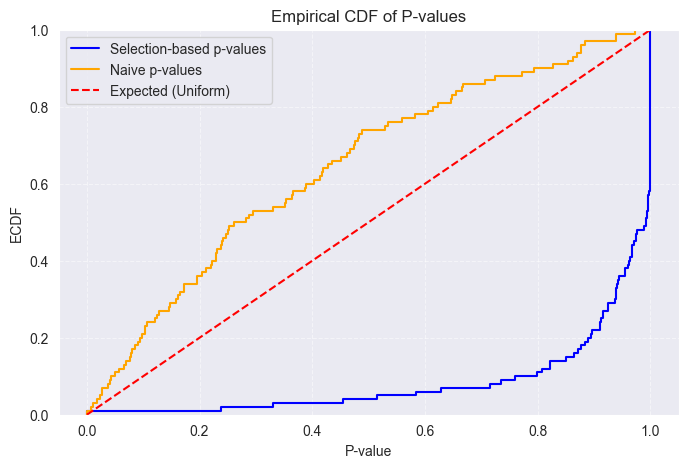

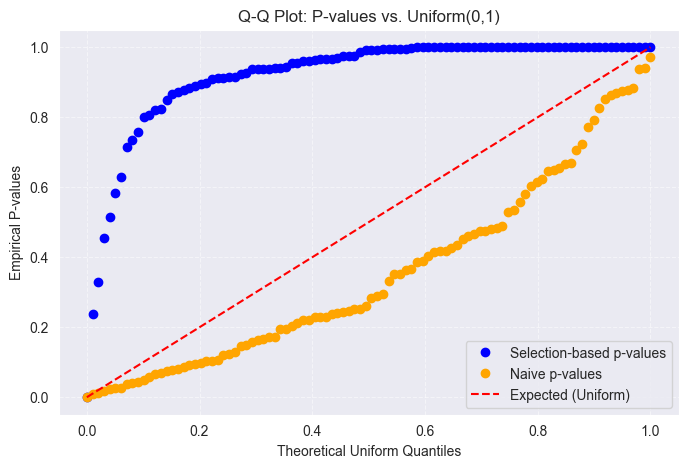

In [52]:
check_p_value_uniformity(20,2,1,5,1,-1,100)

level:  1
-16.29422247556175
-16.29422247556175
435 0
level:  1
-16.29422247556175
8.708714354354354
Original selection probability:  -133.29571176399753
Selection probability:  -46.19938912595411
level:  1
-16.574563226287893
-16.574563226287893
429 0
level:  1
-16.574563226287893
8.588594294294294
Original selection probability:  -135.17101874171908
Selection probability:  -46.52923121734581
level:  1
-16.273759391314023
-16.273759391314023
436 0
level:  1
-16.273759391314023
8.728734364364364
Original selection probability:  -133.17100128347653
Selection probability:  -46.243623522208075
level:  1
-16.40677731867047
-16.40677731867047
430 0
level:  1
-16.40677731867047
8.608614304304304
Original selection probability:  -134.52561343429147
Selection probability:  -46.35950273753777
level:  1
-16.54672888649108
-16.54672888649108
432 0
level:  1
-16.54672888649108
8.648654324324324
Original selection probability:  -134.50824402878538
Selection probability:  -46.48814113787084
level:  

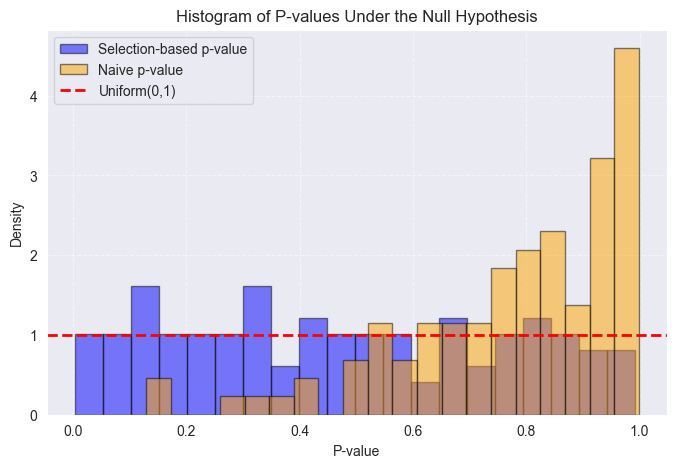

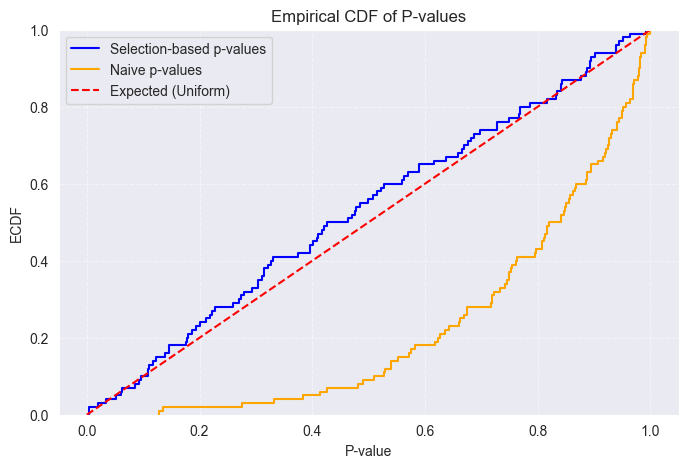

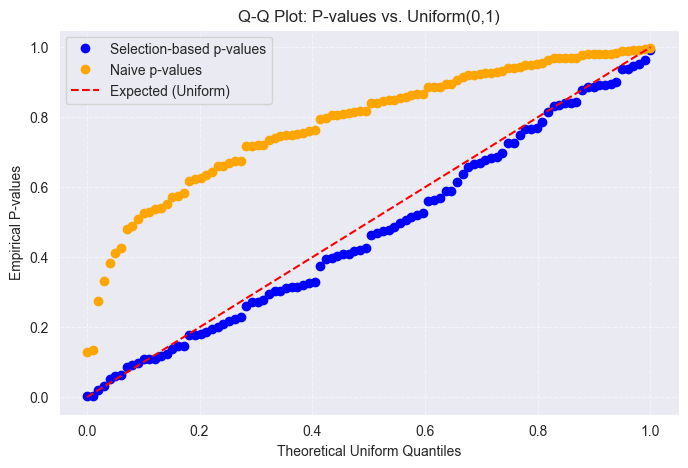

In [3]:
check_p_value_uniformity(20,2,1,19,2,-1,100)

level:  1
Original selection probability:  -131.8611527657415
Selection probability:  0.0
level:  1
Original selection probability:  -133.6259537316093
Selection probability:  0.0
level:  1
Original selection probability:  -132.6419466746645
Selection probability:  0.0
level:  1
Original selection probability:  -133.48663875165198
Selection probability:  0.0
level:  1
Original selection probability:  -133.61091057285284
Selection probability:  0.0
level:  1
Original selection probability:  -136.39953777156495
Selection probability:  0.0
level:  1
Original selection probability:  -133.61430917162158
Selection probability:  0.0
level:  1
Original selection probability:  -132.91768887138358
Selection probability:  0.0
level:  1
Original selection probability:  -134.2040501793707
Selection probability:  0.0
level:  1
Original selection probability:  -134.76961154149058
Selection probability:  0.0
level:  1
Original selection probability:  -133.542039323087
Selection probability:  0.0
level

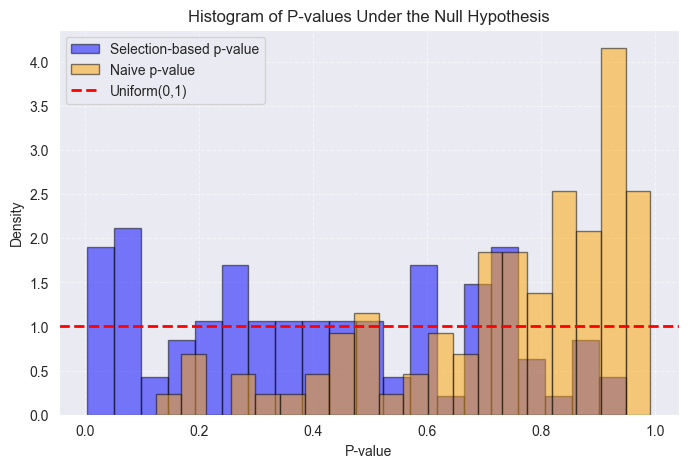

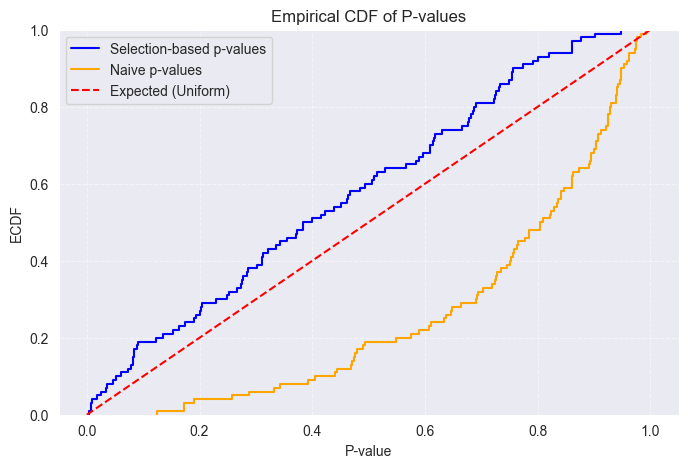

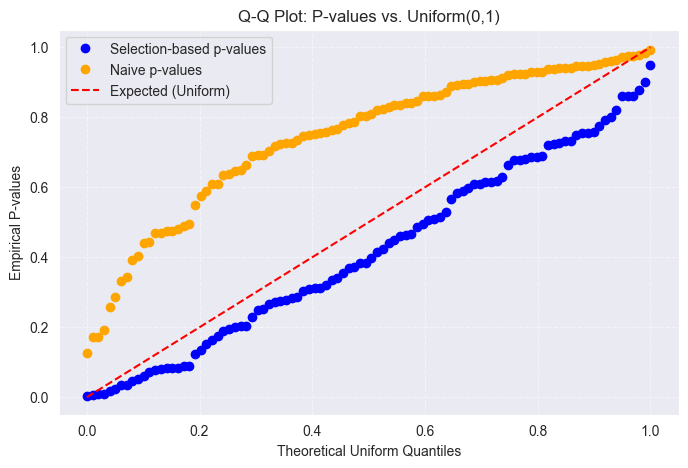

In [3]:
check_p_value_uniformity(20,2,1,19,2,-1,100)

level:  27
level:  26
level:  25
level:  24
level:  23
level:  22
level:  21
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
-251.48846295372002
level:  27
level:  26
level:  25
level:  24
level:  23
level:  22
level:  21
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
-253.61120601944606
level:  27
level:  26
level:  25
level:  24
level:  23
level:  22
level:  21
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
-242.8264484183084
level:  27
level:  26
level:  25
level:  24
level:  23
level:  22
level:  21


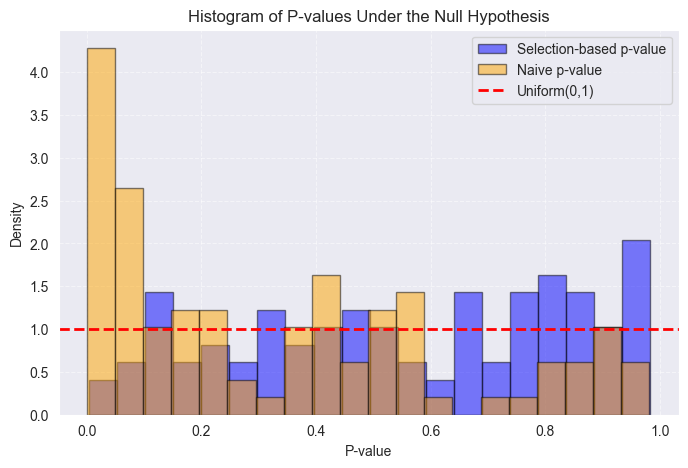

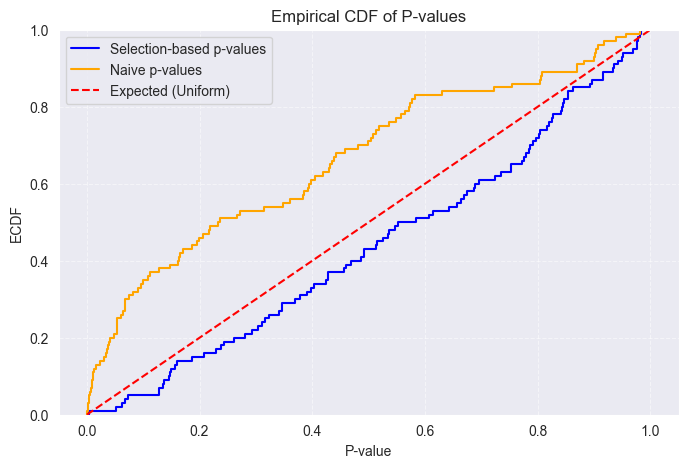

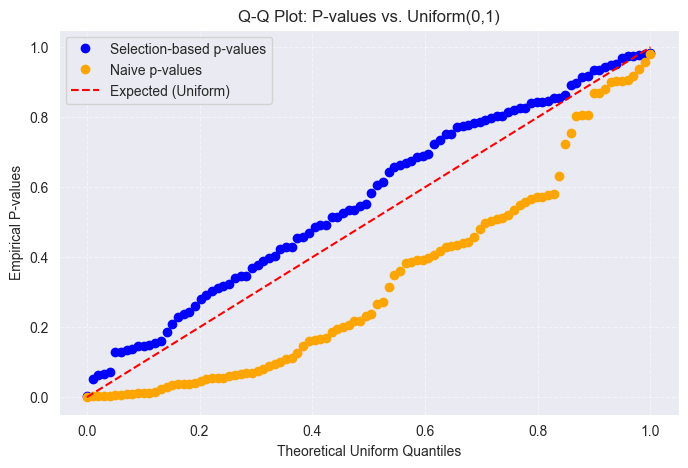

In [3]:
check_p_value_uniformity(30,2,1,3,np.log(20),-1,100)

level:  1
-35.5229219385917
level:  1
-35.344600277085334
level:  1
-35.71303881548485
level:  1
-35.0088997642514
level:  1
-34.19336690522883
level:  1
-34.736499990126184
level:  1
-34.37065224340934
level:  1
-35.369961286741365
level:  1
-34.73780177882011
level:  1
-34.65495568580806
level:  1
-35.5708792800076
level:  1
-35.12057264355608
level:  1
-35.48812609320247
level:  1
-35.21035279098567
level:  1
-35.2602722354736
level:  1
-35.29258294660767
level:  1
-35.03448958966535
level:  1
-35.19224253300523
level:  1
-35.019564366338614
level:  1
-35.173771166138856
level:  1
-35.14188318594466
level:  1
-35.32075423180133
level:  1
-36.80918241079619
level:  1
-34.01005237408559
level:  1
-34.674431528258154
level:  1
-35.88553387178743
level:  1
-34.499939392962276
level:  1
-34.772190471143496
level:  1
-35.516720190470714
level:  1
-35.88000962345382
level:  1
-34.99989078571481
level:  1
-34.75147078414026
level:  1
-34.710572525319776
level:  1
-35.9766241369436
level:  1

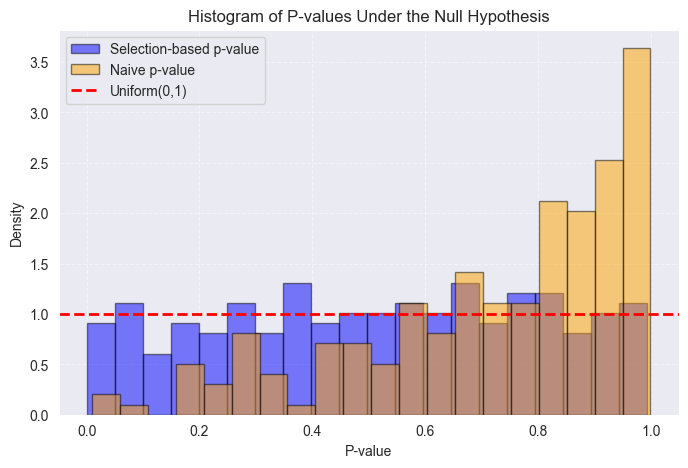

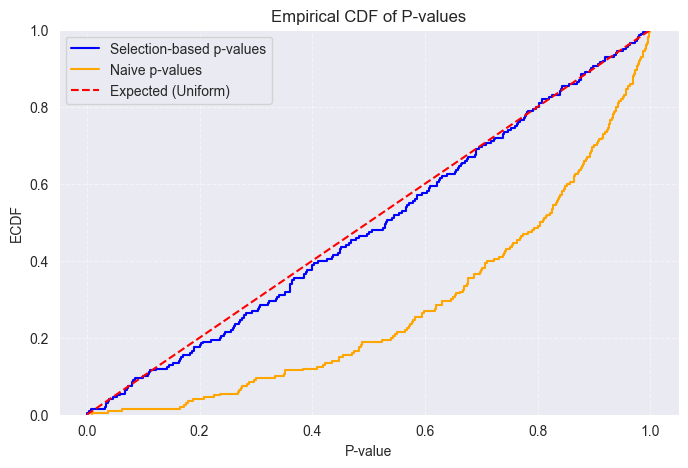

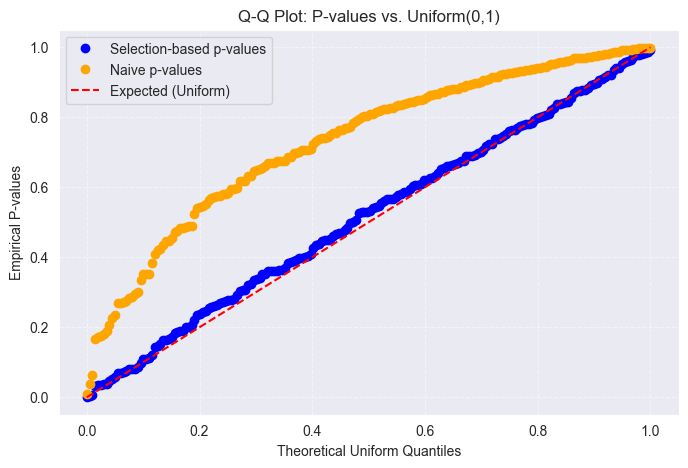

In [3]:
check_p_value_uniformity(20,15,1,19,np.log(20),-1,200)

level:  1
-5.953430953546688
level:  1
-5.918415251688836
level:  1
-5.807449591686842
level:  1
-5.915730866135025
level:  1
-5.847341758964905
level:  1
-5.920512551472791
level:  1
-5.834492977672216
level:  1
-5.777682327491377
level:  1
-5.859740702449299
level:  1
-5.949834556770279
level:  1
-5.799577800479197
level:  1
-5.957126459625757
level:  1
-5.8248720380348376
level:  1
-5.839540166633486
level:  1
-5.7984799409476935
level:  1
-5.824262633699647
level:  1
-5.889510179234982
level:  1
-5.860394555367364
level:  1
-5.8901299547896215
level:  1
-5.810747736295406
level:  1
-5.812850404447378
level:  1
-5.764632948076432
level:  1
-5.901081792221447
level:  1
-5.890703278427624
level:  1
-5.853310299878849
level:  1
-5.786727095190874
level:  1
-5.947115501918756
level:  1
-5.908951522122971
level:  1
-5.8222673266449565
level:  1
-5.875967199016218
level:  1
-5.867689410943708
level:  1
-5.919583560008602
level:  1
-5.877415323649341
level:  1
-5.893952473753313
level:  1


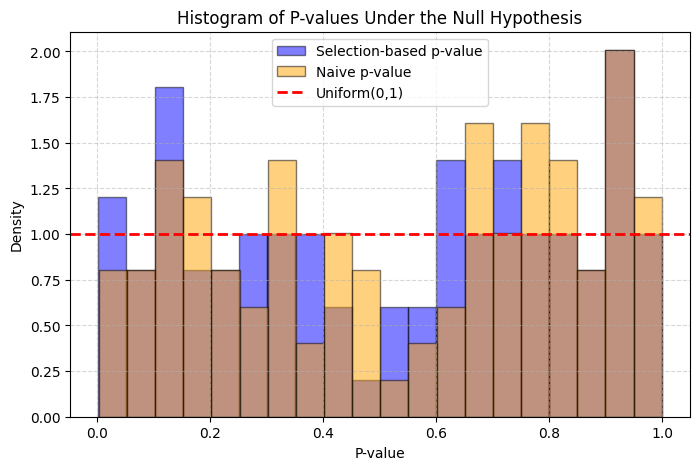

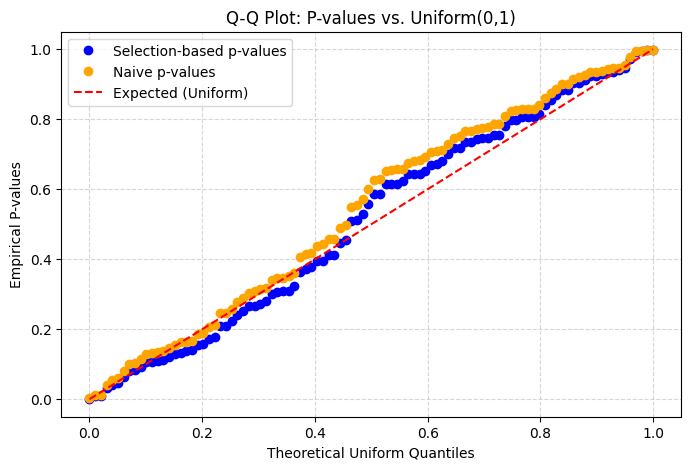

In [87]:
check_p_value_uniformity(20,2,1,19,10,-1,100)

level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
le

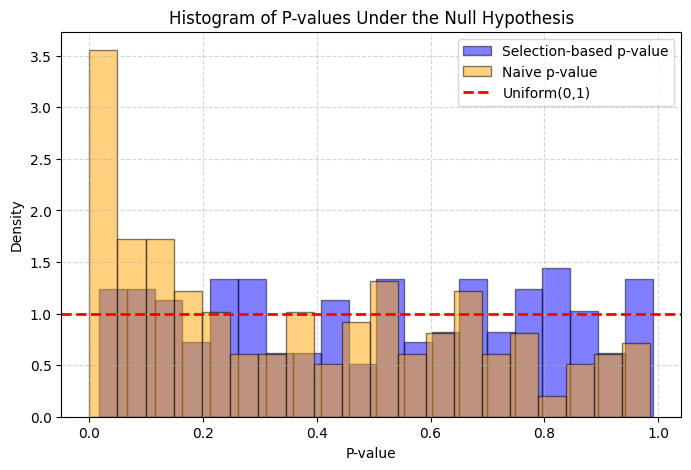

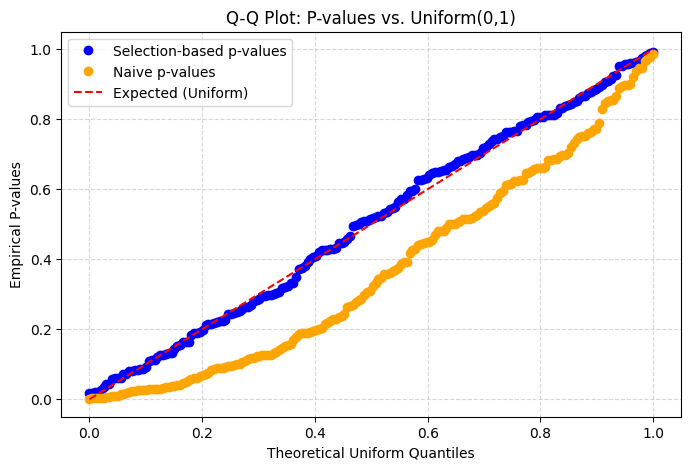

In [31]:
check_p_value_uniformity(20,2,1,3,np.log(20),-1,200)

level:  1
-29.6981013744938
level:  1
-30.30551050885648
level:  1
-30.890393390463764
level:  1
-30.576846549109057
level:  1
-31.461458125334282
level:  1
-30.585953655830323
level:  1
-30.05431092645543
level:  1
-30.08598603872609
level:  1
-30.20889959246029
level:  1
-29.981392245162233
level:  1
-29.3694896518131
level:  1
-30.266857887556206
level:  1
-30.394157241620167
level:  1
-30.869962096853413
level:  1
-30.949051884283055
level:  1
-30.74066576462951
level:  1
-30.591530669894983
level:  1
-31.047628993439737
level:  1
-30.123548300888896
level:  1
-30.080643760290176
level:  1
-29.584204220995595
level:  1
-30.232139399423012
level:  1
-30.657799810301135
level:  1
-30.910552590745944
level:  1
-30.31540656095717
level:  1
-30.45702668606181
level:  1
-30.193149015401588
level:  1
-30.042565823159077
level:  1
-30.223616147492706
level:  1
-30.34048953736898
level:  1
-30.80727943244681
level:  1
-30.67184337089264
level:  1
-30.66019339300873
level:  1
-30.23019732144

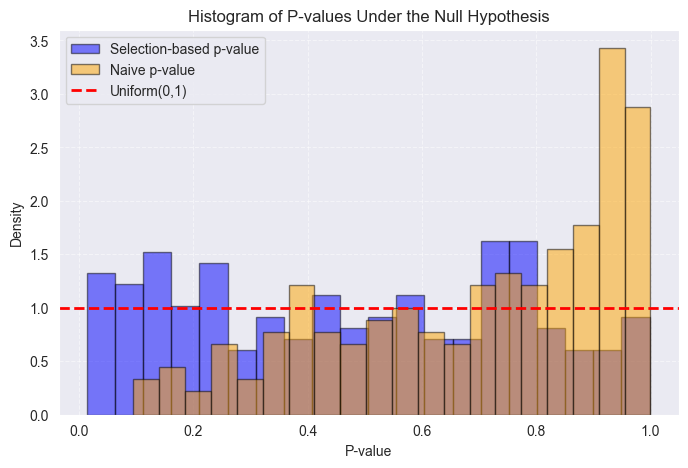

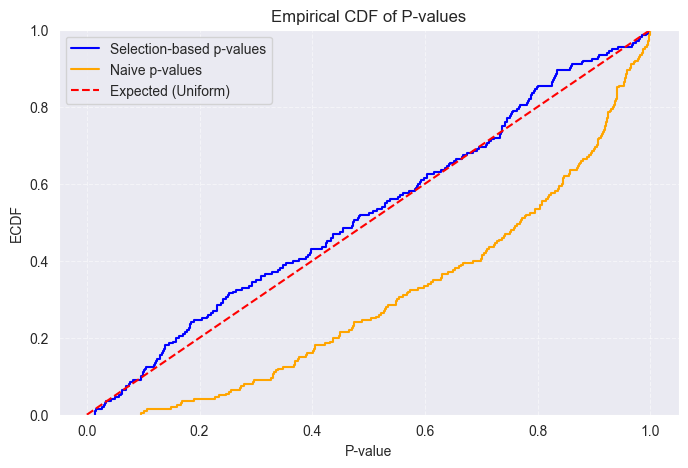

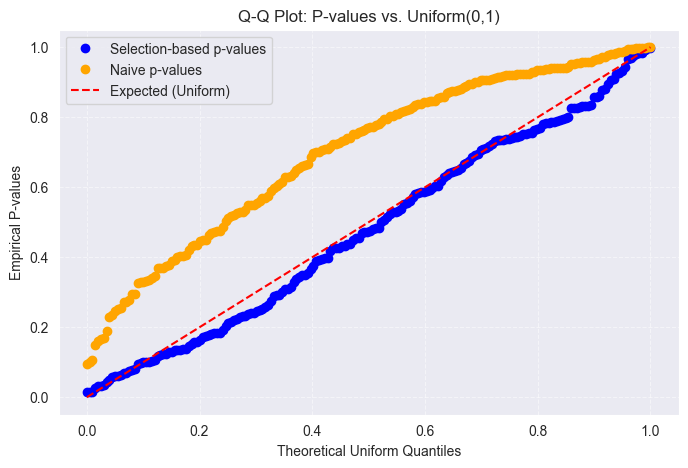

In [30]:
check_p_value_uniformity(20,30,1,19,np.log(20),-1,200)

In [ ]:
np.log(20)

level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6


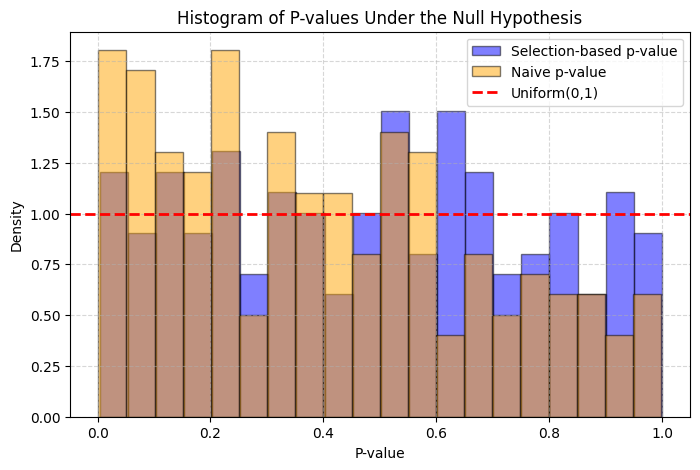

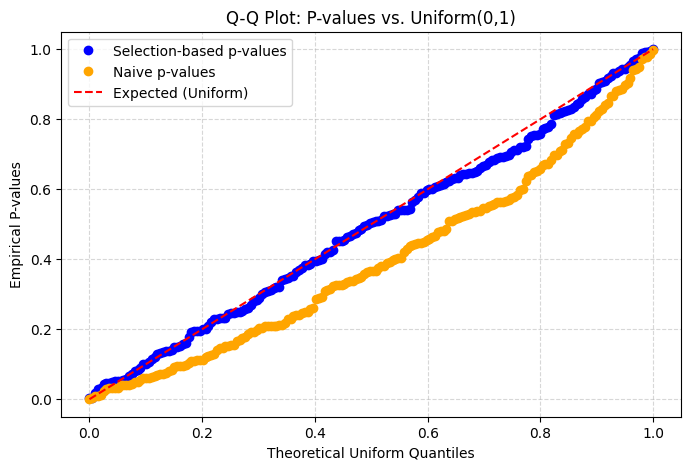

In [35]:
check_p_value_uniformity(10,15,1,3,np.log(10),-1,200)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


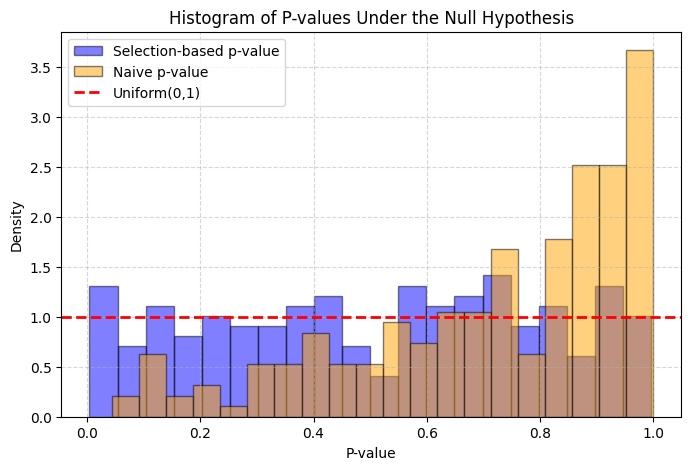

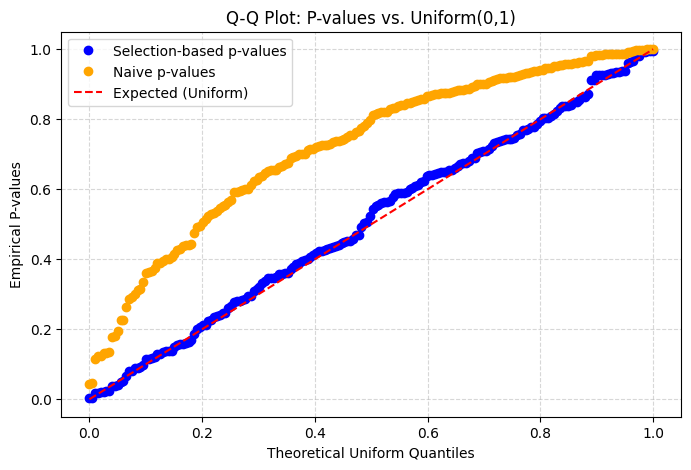

In [37]:
check_p_value_uniformity(20,15,1,19,np.log(20),-1,200)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


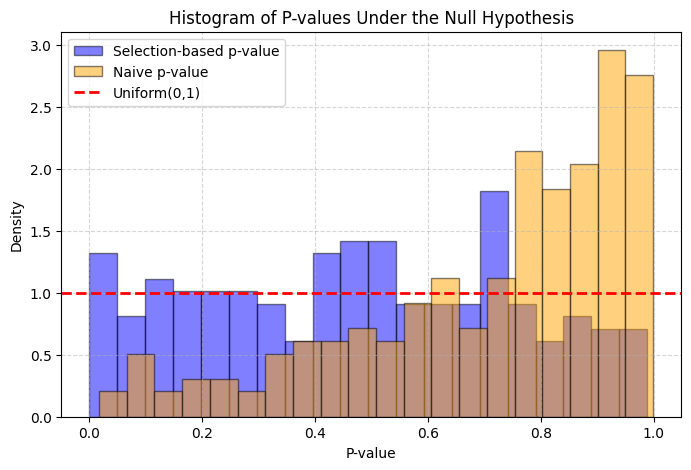

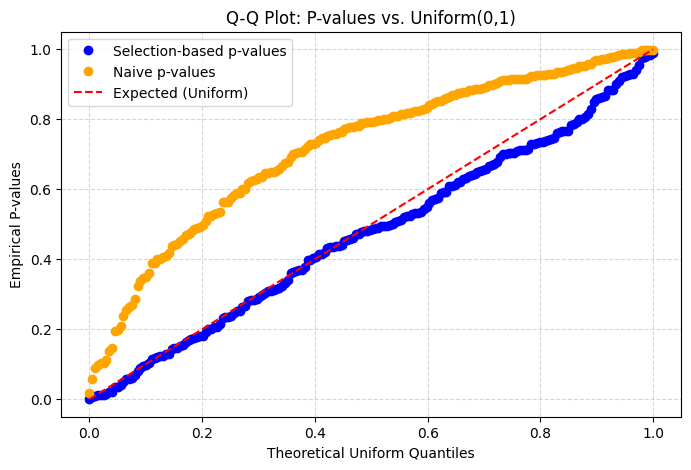

In [26]:
check_p_value_uniformity(30,15,1,29,np.log(30),-1,200)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


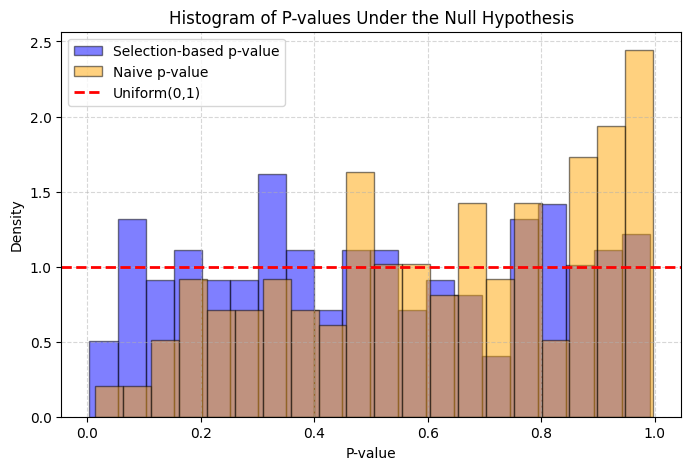

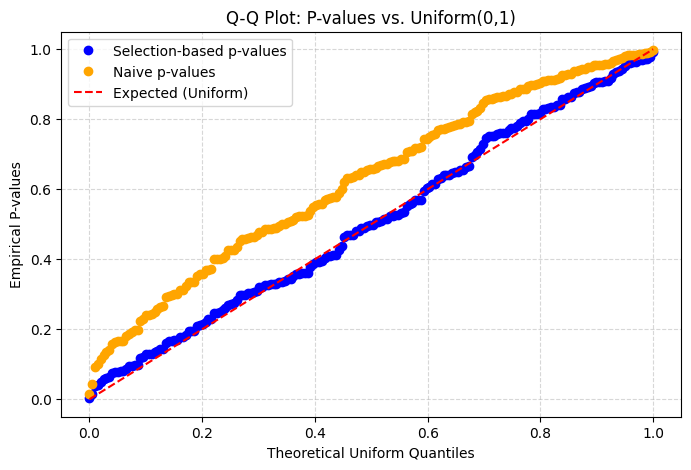

In [28]:
check_p_value_uniformity(30,15,1,29,np.sqrt(30),-1,200)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


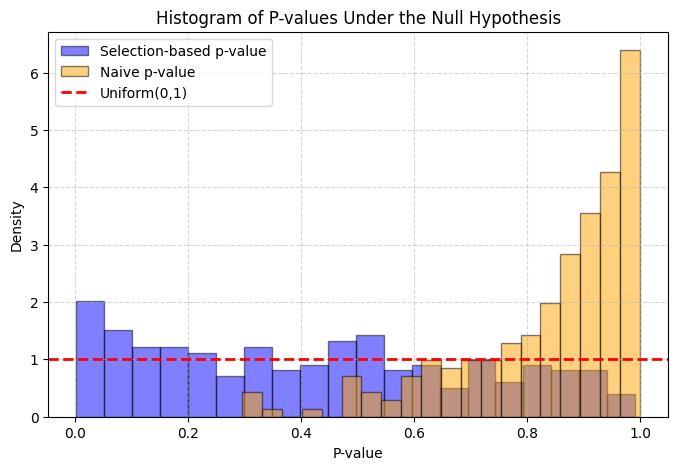

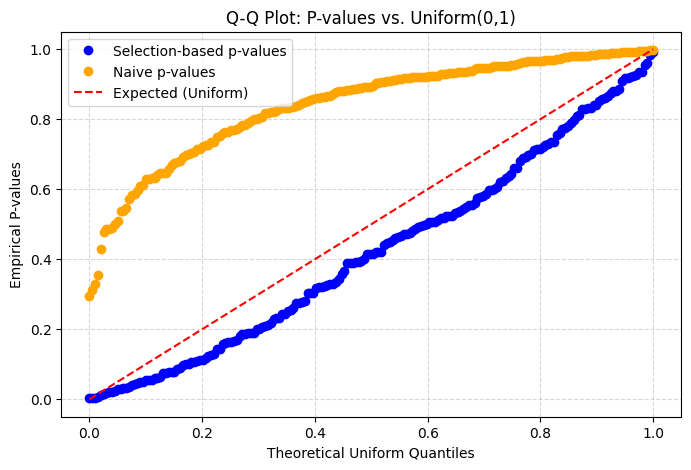

In [51]:
check_p_value_uniformity(10,2,1,9,1,-1,200)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


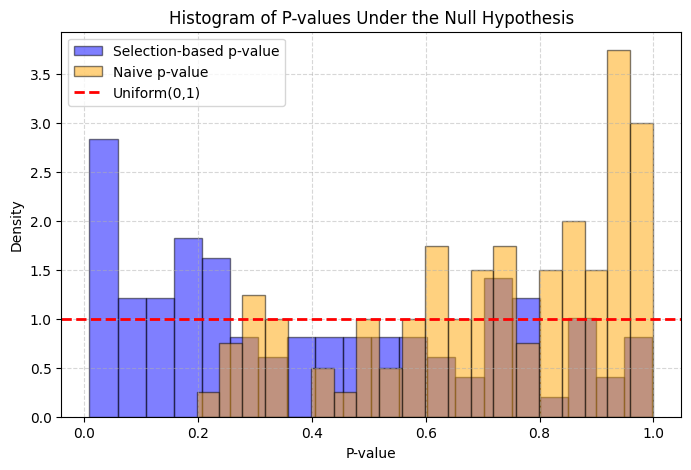

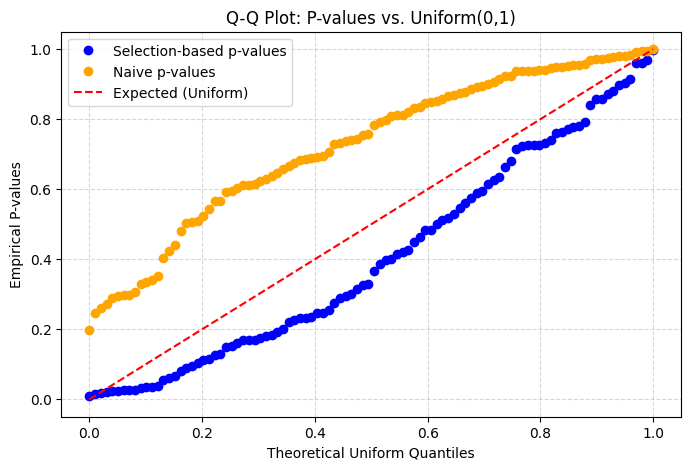

In [48]:
check_p_value_uniformity(20,2,1,19,2,-1,100)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


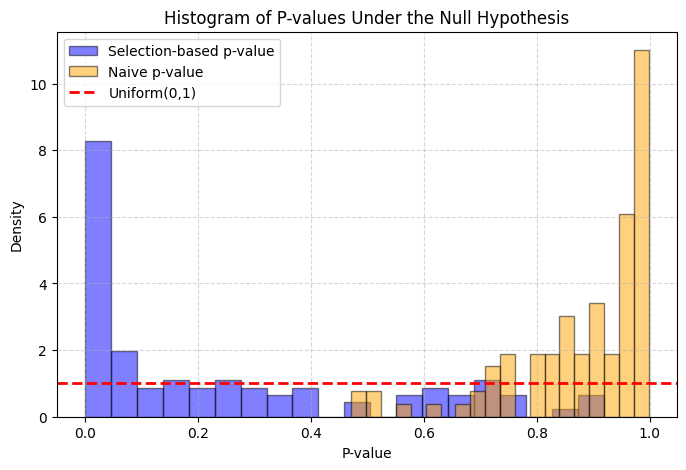

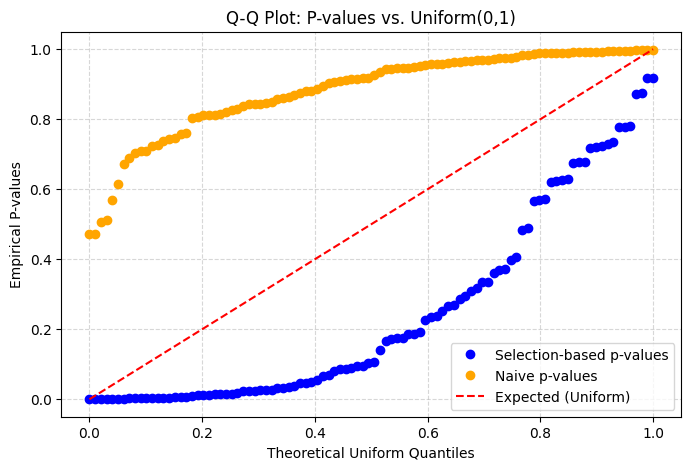

In [50]:
check_p_value_uniformity(30,2,1,29,1,-1,100)

In [ ]:
check_p_value_uniformity(20,2,1,19,5,-1,100)

In [ ]:
check_p_value_uniformity(100,30,1,99,5,-1,50)

In [ ]:
check_p_value_uniformity(20,15,1,10,1*np.sqrt(20),-1,100)

In [ ]:
check_p_value_uniformity(30,15,1,10,1*np.sqrt(30),-1,100)

In [ ]:
check_p_value_uniformity(30,15,1,3,1*np.sqrt(30),-1,200)

In [ ]:
def plot_p_value(stat_grid, cdf, observed_target, p_value):
    observed_cdf_value = np.interp(observed_target, stat_grid, cdf)
    
    plt.figure(figsize=(8, 5))
    
    plt.plot(stat_grid, cdf, label="CDF", color="blue", lw=2)
    plt.axvline(observed_target, color='red', linestyle='dashed', lw=2, label="Observed Target")
    
    plt.fill_between(stat_grid, cdf, 1, where=(stat_grid >= observed_target), color='red', alpha=0.3, label="p-value region")

    plt.text(observed_target, 0.05, f"Observed Target = {observed_target:.3f}", color='red', fontsize=12, rotation=90, verticalalignment='bottom')
    plt.text(stat_grid[-1]*0.85, 0.8, f"p-value = {p_value:.4f}", color='red', fontsize=14, bbox=dict(facecolor='white', edgecolor='red'))

    plt.xlabel(r"$X$ (Test Statistic)")
    plt.ylabel("Cumulative Probability (CDF)")
    plt.title("Visualization of p-value")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
  
    plt.show()

In [ ]:
grid = np.linspace(0.00001, 15, num=1000)

In [ ]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[-1]
node = key[0].parent
pvalue, obs, cdf = model.merge_inference(node)
pvalue

In [ ]:
plot_p_value(grid, cdf, obs, pvalue)

In [ ]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[-1]
node = key[0].parent
pvalue, obs, cdf = model.merge_inference(node)
pvalue

In [ ]:
plot_p_value(grid, cdf, obs, pvalue)

In [ ]:
print("\nExisting Clusters Log:")
for key, value in model.existing_clusters_log.items():
    print(f"Merge: {key} -> Clusters: {value}")

In [ ]:
X, y = make_blobs(n_samples=50, centers=4, cluster_std=1,random_state=42)

# Fit agglomerative clustering
model = AgglomerativeClustering(X, tau=1, n_clusters=3,linkage="single")
model.fit()
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)

# Assign cluster labels from the final cluster nodes
for idx, node in enumerate(model.cluster_nodes):
    for point_index in node.points:
        cluster_labels[point_index] = idx

    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

In [ ]:
pvalue

In [ ]:
plot_p_value(grid, cdf, obs, pvalue)

In [ ]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[3]
node = key[0].parent
pvalue, obs, cdf = model.merge_inference(node)
pvalue

In [ ]:
plot_p_value(grid, cdf, obs, pvalue)

In [ ]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[0]
node = key[0].parent

In [ ]:
node

In [ ]:
model.merge_inference(node)

In [ ]:
model.existing_clusters_log.keys()

In [ ]:
model.distance_matrix

In [ ]:
print("Distance Log:")
for key, value in model.distance_log.items():
    print(f"{key}: {value}")

In [ ]:
print("\nExisting Clusters Log:")
for key, value in model.existing_clusters_log.items():
    print(f"Merge: {key} -> Clusters: {value}")

In [ ]:
print("Randomization Log:")
for key, value in model.randomization_log.items():
    print(f"{key}: {value}")


In [ ]:
model.get_all_winning_pairs()

In [ ]:
np.random.normal(0,1,(10,1))

In [ ]:
X_grid = np.array([
    [-3.41284633,  8.94302295],
    [-6.63766492, -8.79338984],
    [-5.46153354,  8.71814827],
    [-5.59752253,  8.4386312],
    [ 4.17646114,  1.50743993]
])


In [ ]:
from scipy.spatial import distance
data_new_node = X_grid[3,:].reshape(1,-1)
data_cluster = X_grid[[0,2],:]
distances = distance.cdist(data_new_node, data_cluster, metric='euclidean')
        

In [ ]:
distances

In [ ]:
from scipy.spatial import distance
data_new_node = X_grid[0,:].reshape(1,-1)
data_cluster = X_grid[2,:].reshape(1,-1)
distances = distance.cdist(data_new_node, data_cluster, metric='euclidean')
distances

In [ ]:
data_new_node = X[3,:].reshape(1,-1)
data_cluster = X[[0,2],:]
distances = distance.cdist(data_new_node, data_cluster, metric='euclidean')
distances

In [ ]:
data_new_node = X[0,:].reshape(1,-1)
data_cluster = X[2,:].reshape(1,-1)
distances = distance.cdist(data_new_node, data_cluster, metric='euclidean')
distances